#### Гипотеза 1:
Употребление алкоголя до 25 лет (в молодом возрасте) приводит к значительному росту уровня **печеночного фермента gamma_GTP**, тогда как после 25 лет разница роста уровня gamma_GTP между пьющими и непьющими выравнивается.
#### Гипотеза 2:
Пиковые значения **артериального давления (SBP)** и **холестерина (LDL)** приходятся на разные возрастные периоды у мужчин и женщин.
#### Гипотеза 3:
Люди со средними значениями **гемоглобина** (14-16 г/дл) и более высокими значениями имеют лучшие показатели зрения, чем люди с низкими. Причиной этого может быть то, что уровень гемоглобина влияет на насыщение тканей и органов кислородом, поэтому предполагается, что люди с низкими значения гемоглобина будут иметь в среднем более низкие показатели зрения.
#### Гипотеза 4:
Распространенность повышенного **уровня сахара в крови натощак** (BLDS > 100 мг/дл) значительно выше среди людей с вредными привычками (курение и/или алкоголь) по сравнению со здоровой группой. Курение и алкоголь в разной степени влияют на уровень сахара в крови.
#### Гипотеза 5:
Соотношение обхвата талии к росту является более сильным предиктором повышенного уровня триглицеридов и пониженного уровня "хорошего" холестерина, чем просто индекс массы тела или обхват талии по отдельности.

sex (Пол)

age (Возраст)

height (Рост)

weight (Вес)

waistline (Обхват талии)

sight_left (Зрение левый глаз)

sight_right (Зрение правый глаз)

hear_left (Слух левое ухо)

hear_right (Слух правое ухо)

SBP (Систолическое давление)

DBP (Диастолическое давление)

BLDS (Сахар в крови натощак)

tot_chole (Общий холестерин)

HDL_chole (Холестерин ЛПВП, "хороший")

LDL_chole (Холестерин ЛПНП, "плохой")

triglyceride (Триглицериды)

hemoglobin (Гемоглобин)

urine_protein (Белок в моче)

serum_creatinine (Креатинин в сыворотке)

SGOT_AST (АСТ): Печеночный фермент

SGOT_ALT (АЛТ): Печеночный фермент

gamma_GTP (ГГТ): Печеночный фермент

SMK_stat_type_cd (Статус курения) (0 - не курит, 1 - курил раньше, 2 - курит)

DRK_YN (Употребление алкоголя) (Y - курит, N - не курит)

#### Импортируем неободимые библиотеки:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('smoking_driking_dataset_Ver01.csv')
df.head(3)

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N


In [3]:
df.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

Переведем нечисловые столбцы в числовые

In [4]:
df_ren = df.rename(columns={
    'sex': 'is_male',
    'DRK_YN': 'drink'
})

df_ren['is_male'] = df_ren['is_male'].map({
    'Male': 1,
    'Female': 0
})

df_ren['drink'] = df_ren['drink'].map({
    'Y': 1,
    'N': 0
})

df_ren.head(3)

,is_male,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,drink
0,1,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,1
1,1,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,0
2,1,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,0


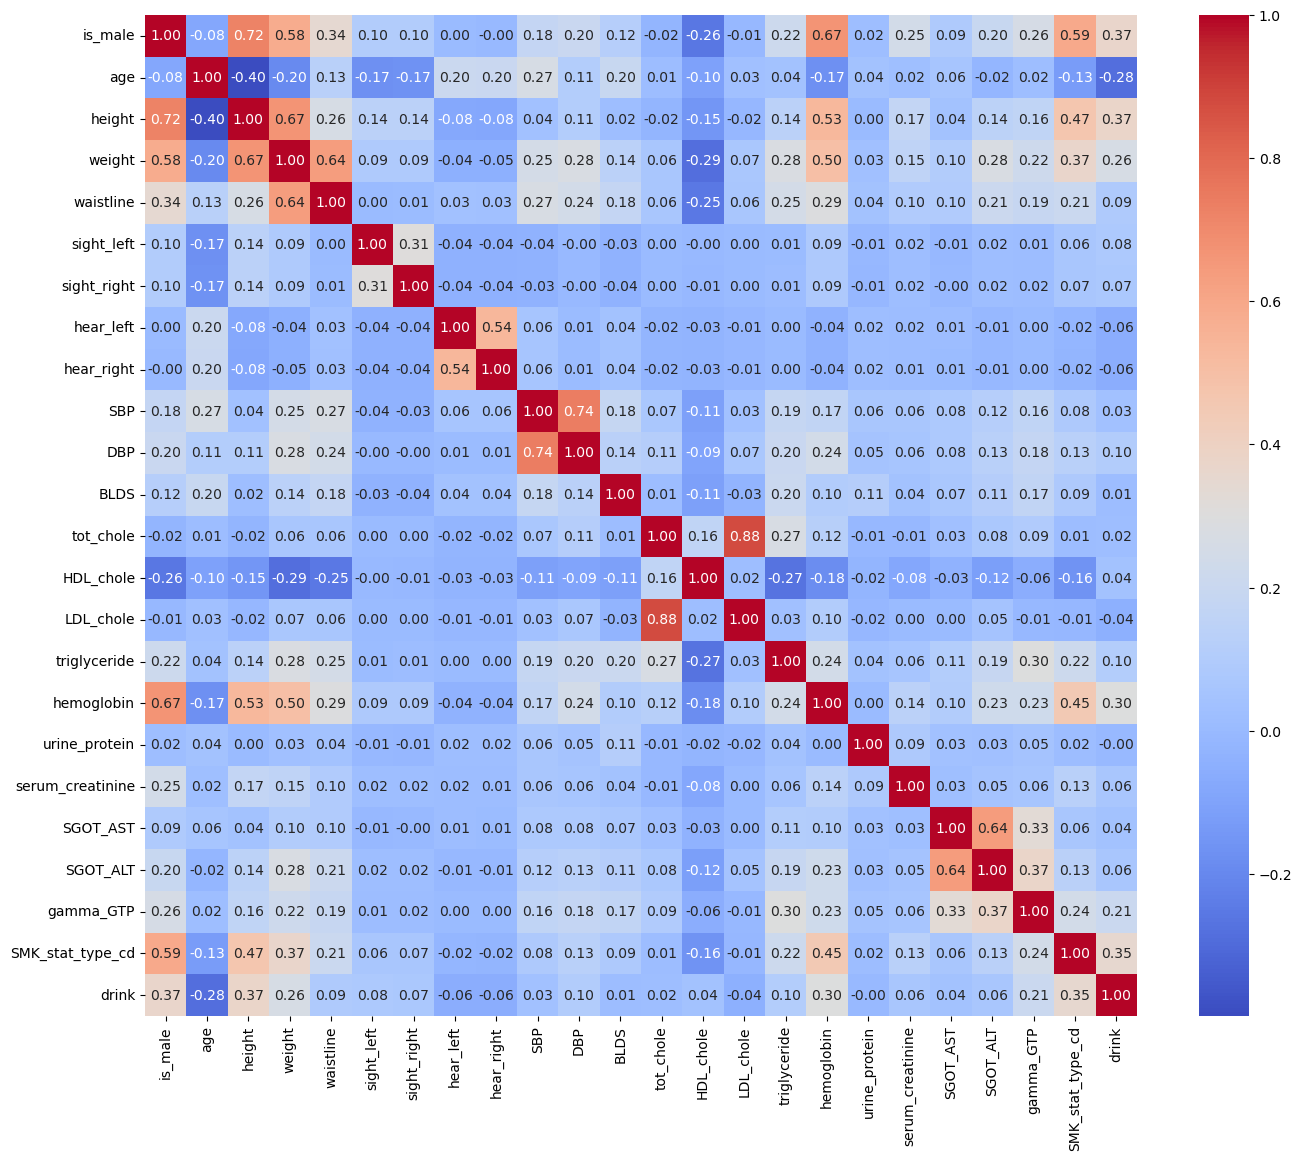

In [5]:
corr = df_ren.corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

# Гипотеза 1:
Употребление алкоголя до 25 лет (в молодом возрасте) приводит к значительному росту уровня **печеночного фермента gamma_GTP**, тогда как после 25 лет разница роста уровня gamma_GTP между пьющими и непьющими становиться менее значимой. 

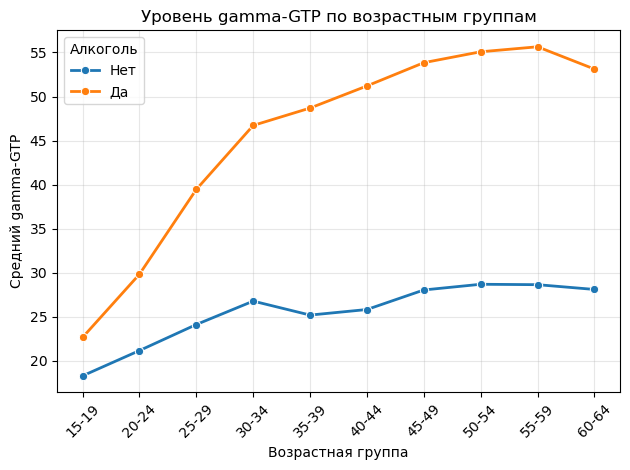

In [ ]:
df_ren['age_group'] = pd.cut(df_ren['age'], 
                             bins=range(15, 70, 5), 
                             labels=['15-19','20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64'])

age_gamma = df_ren.groupby(['age_group', 'drink'], observed=False)['gamma_GTP'].mean().reset_index()

sns.lineplot(data=age_gamma, x='age_group', y='gamma_GTP', hue='drink', 
             marker='o', linewidth=2, markersize=6)

plt.title('Уровень gamma-GTP по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Средний gamma-GTP')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Нет', 'Да'], title='Алкоголь')

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

>Уроваень печеночного фермента значимо различается у пьющих и непьющих. В период с 15 до 35 лет у непьющих в среднем изменился уровень gamma_GTP с 15 до 27 (на 12), в то время как у пьющих - с 23 до 43 (на 20). В возрасте от 35 до 60 к непьющих относительно стабильный уровень в среднем (примерно на уровне 25-29), в то время как у пьющих среднйи уровень gamma_GTP продолжает повышаться, имея средний показатель в возрасте 30-34 около 43 и достигая 56 в возрасте 55-59. Это практически вдвое больше, чем у тех, кто не употребляет алкоголь.

**Гипотеза подтверждена.** *Это свидетельствует о том, что алкоголь оказывает значительное влияние на уровень печеночного фермента gamma_GTP, особенно в молодом возрасте до 35, что подтверждает исследования о большем вреде алкоголя на молодой организм. Кроме того в более позднем возрасте у непьющих показатель gamma_GTP становиться достаточно стабильным, пока у тех, кто употребляет алкоголь он растет, хотя и медленнее с возрастом. Это доказывает важность осторожности в употреблении алкоголя, особенно в сравнительно молодом возрасте, так как именно тогда алкоголь оказывает сильнейшее влияние на здоровье, в частности печени.*


# Гипотеза 2:
Пиковые значения **артериального давления (SBP)** и **холестерина (LDL)** приходятся на разные возрастные периоды у мужчин и женщин.

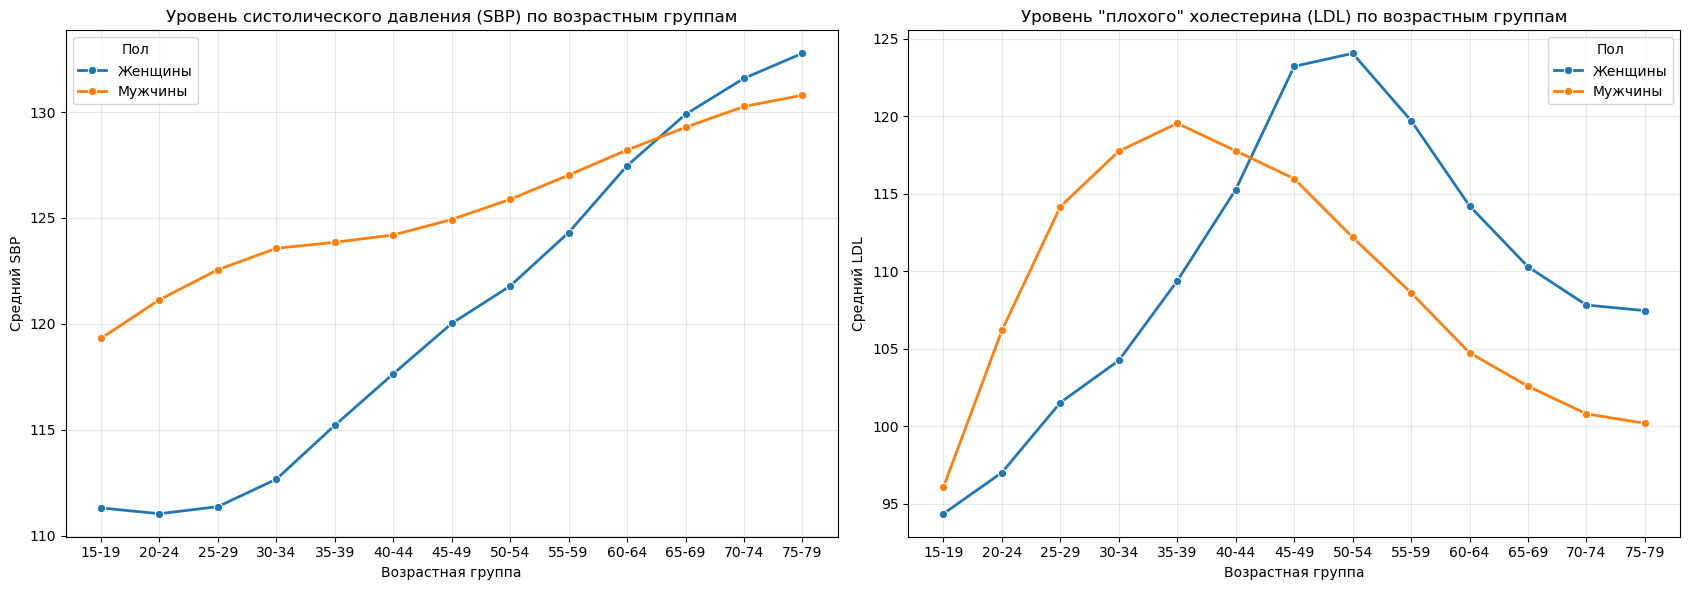

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

df_ren['age_group'] = pd.cut(df_ren['age'], 
                             bins=list(range(15, 81, 5)), 
                             labels=['15-19','20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79'])

age_sbp = df_ren.groupby(['age_group', 'is_male'], observed=False)['SBP'].mean().reset_index()

sns.lineplot(data=age_sbp, x='age_group', y='SBP', hue='is_male', 
             marker='o', linewidth=2, markersize=6, ax=ax1)

age_ldl = df_ren.groupby(['age_group', 'is_male'], observed=False)['LDL_chole'].mean().reset_index()

# Линейный график среднего уровня gamma_GTP по возрастным группам
sns.lineplot(data=age_ldl, x='age_group', y='LDL_chole', hue='is_male', 
             marker='o', linewidth=2, markersize=6, ax=ax2)

ax1.set_xlabel('Возрастная группа')
ax1.set_ylabel('Средний SBP')
ax2.set_xlabel('Возрастная группа')
ax2.set_ylabel('Средний LDL')
ax1.set_title('Уровень систолического давления (SBP) по возрастным группам')
ax2.set_title('Уровень "плохого" холестерина (LDL) по возрастным группам')
handles, _ = plt.gca().get_legend_handles_labels()
ax1.legend(handles=handles, title='Пол', labels=['Женщины', 'Мужчины'])
ax2.legend(handles=handles, title='Пол', labels=['Женщины', 'Мужчины'])
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Систолическое давление (SBP):
>Мужчины в среднем еще с раннего возраста имеют более высокое систолическое давление, чем женщины того же возраста. (Так среднее систолическое давление в возрасте от 15 до 19 лет у женщин составляет в среднем около 111 мм рт. ст., тогда как у мужчино около 119 мм рт. ст., а в период с 25 до 29 лет разница между мужчинами и женщинами составляет около 11.5 мм рт. ст.). Кроме того стоит отметить, что с возрастом давление у межчин растет значительно медленнее, чем у женщин и становиться примерно одинаковым 65-69 годам, достигая 130 мм рт. ст. Тем не менее, пикового значения не найти, так как среднее давление безостоновочно растет с возрастом. 

*Мужчины начинают с более высоких показателей, а женщины демонстрируют более высокий рост давления с возрастом, догоняя мужчин к пожилому возрасту. Это соответсвует исследованиям, в которых выяснилось, что мужчины больше подвержены к сердечно-сосудистым заболеваниям, начиная со среднего возраста, чем женщины, так как давление играет большую роль в работе сердечно-сосудистой системы и является одним из показателей ее здоровья. То, что давление не вызодит "на плато" свидетельствует о том, что проблемы с давлением с возрастом только растут и указывает на важность заботы о сердечно-сосудистой системе, особенно учитывая, что ее заболевания возглавляют список причин смерти.*


#### "Плохой холестерин" (LDL):

>Уровень LDL у мужчин в период с 15 до 39 лет достаточно быстро растет (с 96 до 119 мг/дл), после чего идет только на снижение и более не растет. Наибольший прирост с 15 до 29 лет. Пиковое значение приходится на период с 35 до 39 лет (около 119 мг/дл). В случае женщин, LDL растет почти ленейно с 15 до 49 лет, и в возрасте 50-54 лет достигает пикового значения в 124 мг/дл, после чего снижается примерно с той же скоростью, как у мужчин. 

*Разные пики LDL объясняются гормональными различиями. Кроме того пик примерно в 50-55 лет может объяснять, почему женщины "догоняют" мужчин по риску сердечно-сосудистых заболеваний к 50+ годам, что связанно с графиком систолического давления. То, что после 50 лет показатель LDL у мужчин становиться на 10-15 меньше, чем у женщин может также объясняться тем, что мужчины обычно более активны в пожилом возрасте, а женщины чаще них набирают вес и снижают активность. Также, с эволюционной точки зрения, более ранний пик LDL мужчин связан с важностью репродуктивной функции в молодом возрасте, тогда как более поздний пик у женщин связан с большей продолжительностью жизни из-за заботы о потомстве.*

**Таким образом, гипотеза частично подтверждена. В случае с LDL пиковые значения действительно приходятся на разные возрастные периоды у мужчин и женщин. В случае же систолического давления давление непрерывно растет с возрастом и пиковых значений нет, но видны значимые различия в возрастной динамике.**

# Гипотеза 3:
Люди со средними значениями **гемоглобина** (14-16 г/дл) и более высокими значениями имеют лучшие показатели зрения, чем люди с низкими. Причиной этого может быть то, что уровень гемоглобина влияет на насыщение тканей и органов кислородом, поэтому предполагается, что люди с низкими значения гемоглобина будут иметь в среднем более низкие показатели зрения.

In [14]:
df.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


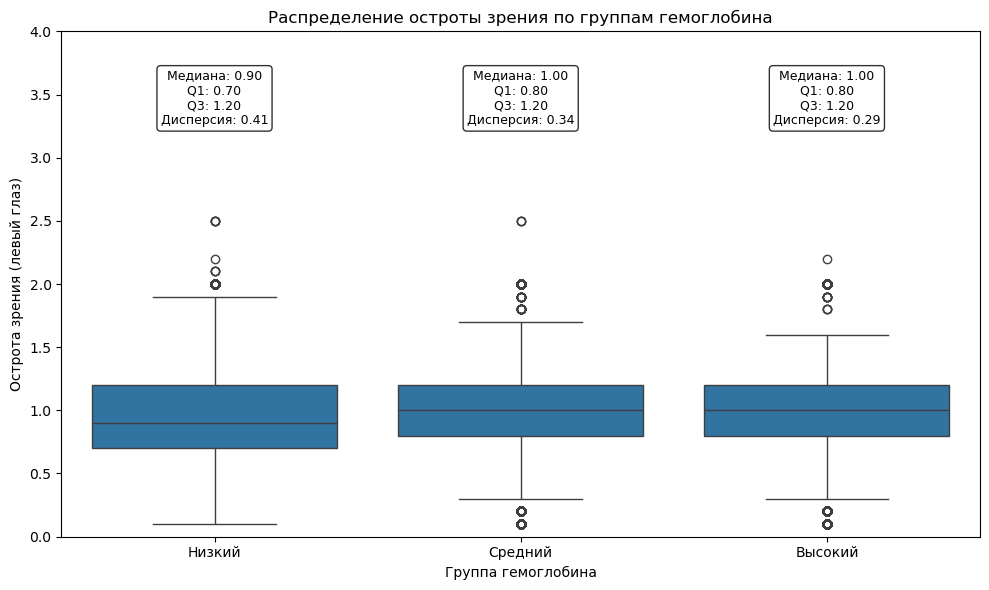

In [20]:
bins = [-np.inf, 14, 16, np.inf]
labels = ["Низкий", "Средний", "Высокий"]
df['hemoglobin_group'] = pd.cut(df['hemoglobin'], bins=bins, labels=labels, right=False)


plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hemoglobin_group', y='sight_left')
plt.title('Распределение остроты зрения по группам гемоглобина')
plt.xlabel('Группа гемоглобина')
plt.ylabel('Острота зрения (левый глаз)')
plt.ylim(0, 4)

# Вычисляем статистики для каждой группы
groups = df['hemoglobin_group'].cat.categories
for i, group in enumerate(groups):
    group_data = df[df['hemoglobin_group'] == group]['sight_left']
    q1 = group_data.quantile(0.25)
    median = group_data.median()
    q3 = group_data.quantile(0.75)
    variance = group_data.var()
    stats_text = f'Медиана: {median:.2f}\nQ1: {q1:.2f}\nQ3: {q3:.2f}\nДисперсия: {variance:.2f}'
    
    plt.text(x=i,
             y=3.7, 
             s=stats_text, 
             ha='center', 
             va='top', 
             bbox=dict(boxstyle="round", 
                       facecolor="white", 
                       alpha=0.8),
             fontsize=9)

plt.tight_layout()
plt.show()

На графике видно:

> Низкая группа (<14 г/дл): Медиана = 0.9 (худшее зрение), наибольший разброс
> 
> Средняя группа (14-16 г/дл): Медиана = 1.0 (лучшее зрение), средний разброс
> 
> Высокая группа (>16 г/дл): Медиана = 1.0 (лучшее зрение), небольшой разброс

**Предположение о том, что низкий уровень гемоглобина пагубно влияет на зрение подтвердилось.**  *Действительно, не только медиана низкой группы оказалась дальше от 1 (идеального зрения), но и дисперсия оказалась значительно сильнее, чем у тех, у кого показатель гемоглобина не менее 14 г/дл. Похоже, что это вызвано гипоксией сетчатки (недостаточным насыщением кислородом) и других частей зрительной системы. Это может говрить о том, что лечение анемии может улучшить зрительные функции. Медиана средней и высокой группы одинакова, но дисперсия высокой группы меньше (значения ближе к медиане, а значит и к наилучшему зрению), что также свидетельствует о том, что чем выше гемоглобин, тем лучше для зрения.*

# Гипотеза 4:
Распространенность повышенного **уровня сахара в крови натощак** (BLDS > 100 мг/дл) значительно выше среди людей с вредными привычками (курение и/или алкоголь) по сравнению со здоровой группой. Курение и алкоголь в разной степени влияют на уровень сахара в крови.


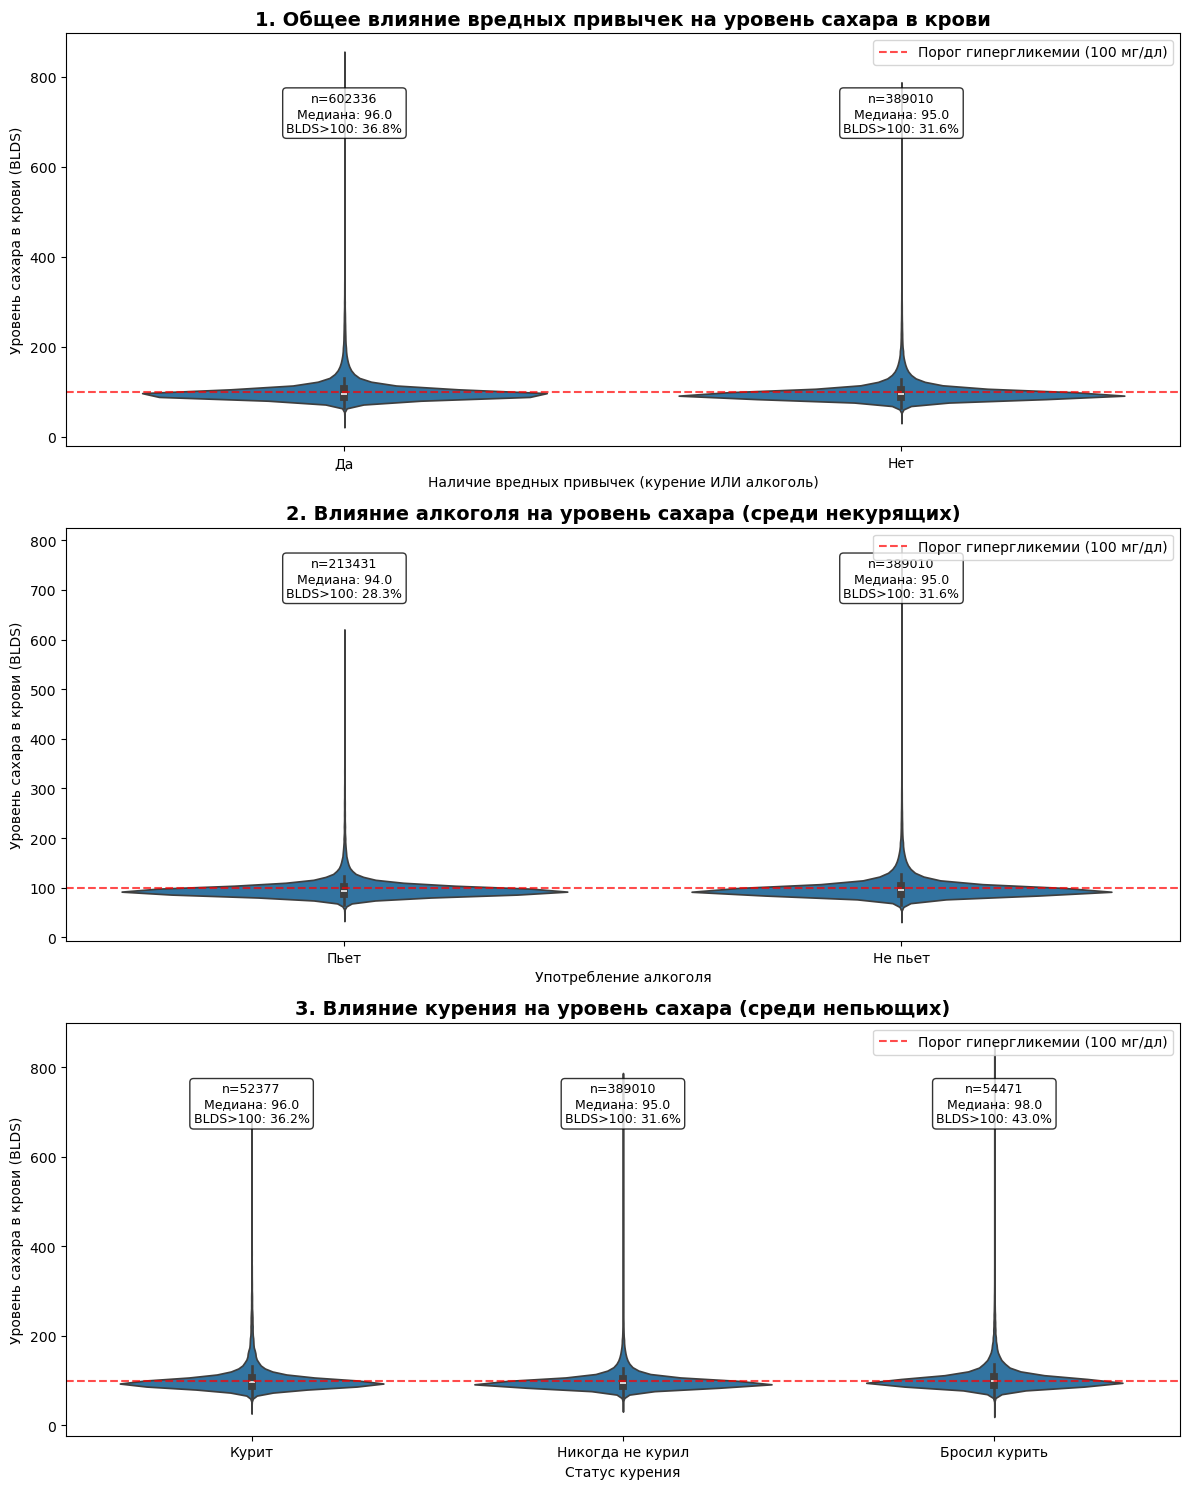

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

plt.sca(axes[0])
df["bad_habits"] = np.where((df['SMK_stat_type_cd'] == 1.0) & (df['DRK_YN'] == 'N'), "Нет", "Да")
sns.violinplot(data=df, x='bad_habits', y="BLDS")
plt.title('1. Общее влияние вредных привычек на уровень сахара в крови', fontsize=14, fontweight='bold')
plt.xlabel('Наличие вредных привычек (курение ИЛИ алкоголь)')
plt.ylabel('Уровень сахара в крови (BLDS)')
plt.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Порог гипергликемии (100 мг/дл)')
plt.legend()

groups1 = df['bad_habits'].unique()
for i, group in enumerate(groups1):
    group_data = df[df['bad_habits'] == group]['BLDS'].dropna()
    n = len(group_data)
    median = group_data.median()
    high_sugar_pct = (group_data > 100).mean() * 100
    stats_text = f'n={n}\nМедиана: {median:.1f}\nBLDS>100: {high_sugar_pct:.1f}%'
    plt.text(x=i, y=df['BLDS'].max() * 0.9, s=stats_text, ha='center', va='top', 
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8), fontsize=9)


plt.sca(axes[1])

alcohol_data = df[df['SMK_stat_type_cd'] == 1.0].copy()
alcohol_data['alcohol_group'] = np.where(alcohol_data['DRK_YN'] == 'Y', 'Пьет', 'Не пьет')

sns.violinplot(data=alcohol_data, x='alcohol_group', y="BLDS")
plt.title('2. Влияние алкоголя на уровень сахара (среди некурящих)', fontsize=14, fontweight='bold')
plt.xlabel('Употребление алкоголя')
plt.ylabel('Уровень сахара в крови (BLDS)')
plt.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Порог гипергликемии (100 мг/дл)')
plt.legend()

groups2 = alcohol_data['alcohol_group'].unique()
for i, group in enumerate(groups2):
    group_data = alcohol_data[alcohol_data['alcohol_group'] == group]['BLDS'].dropna()
    n = len(group_data)
    median = group_data.median()
    high_sugar_pct = (group_data > 100).mean() * 100
    stats_text = f'n={n}\nМедиана: {median:.1f}\nBLDS>100: {high_sugar_pct:.1f}%'
    plt.text(x=i, y=df['BLDS'].max() * 0.9, s=stats_text, ha='center', va='top', 
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8), fontsize=9)


plt.sca(axes[2])
smoking_data = df[df['DRK_YN'] == 'N'].copy()

def get_smoking_group(smk_status):
    if smk_status == 1.0:
        return 'Никогда не курил'
    elif smk_status == 2.0:
        return 'Бросил курить'
    else:
        return 'Курит'

smoking_data['smoking_group'] = smoking_data['SMK_stat_type_cd'].apply(get_smoking_group)

sns.violinplot(data=smoking_data, x='smoking_group', y="BLDS")
plt.title('3. Влияние курения на уровень сахара (среди непьющих)', fontsize=14, fontweight='bold')
plt.xlabel('Статус курения')
plt.ylabel('Уровень сахара в крови (BLDS)')
plt.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Порог гипергликемии (100 мг/дл)')
plt.legend()

groups3 = smoking_data['smoking_group'].unique()
for i, group in enumerate(groups3):
    group_data = smoking_data[smoking_data['smoking_group'] == group]['BLDS'].dropna()
    n = len(group_data)
    median = group_data.median()
    high_sugar_pct = (group_data > 100).mean() * 100
    stats_text = f'n={n}\nМедиана: {median:.1f}\nBLDS>100: {high_sugar_pct:.1f}%'
    plt.text(x=i, y=df['BLDS'].max() * 0.9, s=stats_text, ha='center', va='top', 
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8), fontsize=9)

plt.tight_layout()
plt.show()


#### На 1м графике:
>В категории тех, кто употрбляет алкоголь и курит/курил, медианное значение составляет 96 и доля людей с гипергликемией составляет 36.8%.
>
>В категории здоровых людей медианное значение - 95, доля людей с гипергликемией составляет 31.6%.

### **В группе с вредными привычками гипергликемия встречается на 16.5% чаще**, что составляет значимую разницу, из-за чего гипотеза о погубном влиянии вредных привычек на повышенный уровень сахара в крови подтверждается.

#### Влияют ли алкоголь и курение в равной степени на уровень сахара в крови?
#### На 2м графике люди поделены на употребляющих алкоголь и не употребляющих (при этом курящие исключены из выборки для чистоты анализа)
>Медианное значение непьющих составляет 95, а доля людей с гипергликемией составляет 31.6%
>
>Медианное значение непьющих составляет 94, а доля людей с гипергликемией составляет 28.3%

###  Получается, что у людей, употребляющих алкоголь ниже процент людей с повышенным уровнем сахара в крови! Это интересный результат, и он может быть связан с тем, что алкоголь может не оказывать сильного влияния на уровень сахара в крови, а любители алкоголя могут иметь меньшее пристрастие к сладкой еде и напиткам, чем те, кто алкоголь не употребляют. Но из прошлого графика было видно, что вредные привычки повышают шанс гипергликемии! Значит ли это, что курение оказывает сильное влияние на уровень сахара в крови?

#### На третьем графике видно:
>Люди, которые никогда не курили имеют медианное значение 95 и доля людей с гипергликемией составляет 31.6%
>
>Люди, которые бросили курение имеют медианное значение 98 и доля людей с гипергликемией составляет 43.0%
>
>Люди, которые никогда не курили имеют медианное значение 96 и доля людей с гипергликемией составляет 36.2%

#### Действительно, люди, которые не курили страдают от гипергликемии реже. Но нужно заметить, что доля больных гипергликемией среди бросивших курить значительно больше чем даже у тех, кто продолжает курение! Это может говорить о том, что люди начинают бросать курение, когда у них уже появляются значительные проблемы со здоровьем, а курение оказывает сильное влияние на уровень сахара в крови. Кроме того, возможно,  отказ от курения сильно влияет на метаболизм. **Таким образом у бросивших курить гипергликемия встречается на 36.1% чаще, чем у никогда не куривших**. Это подтверждает гипотезу о том, что курение и алкоголь в разной степени влияют на уровень сахара в крови и говорит о том, что на уровень сахара в крови гораздо сильнее влияет курение, чем алкоголь.

# Гипотеза 5:
#### Соотношение обхвата талии к росту является более сильным предиктором пониженного уровня "хорошего" холестерина, чем просто индекс массы тела или обхват талии по отдельности.

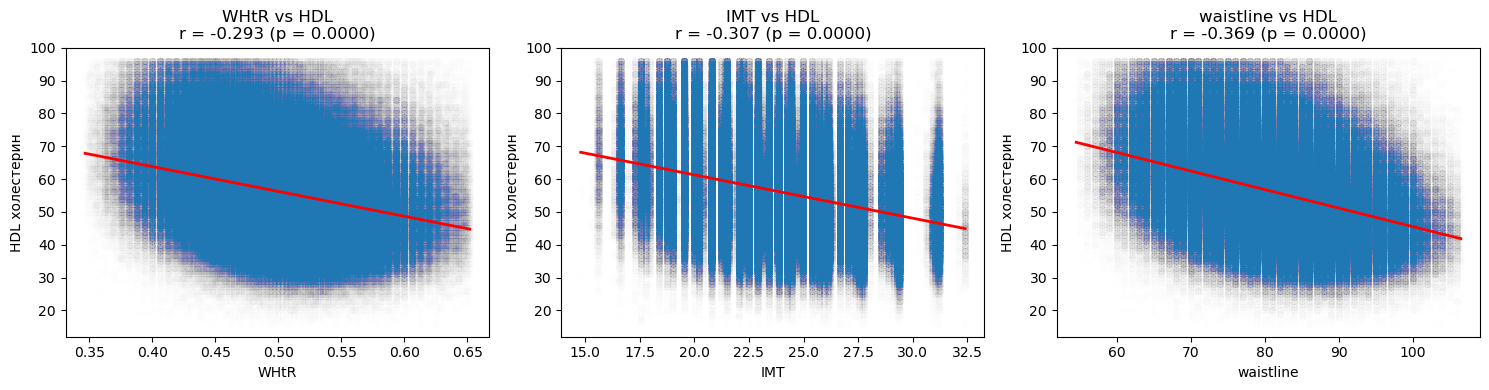

СРАВНЕНИЕ КОРРЕЛЯЦИЙ:
WHtR      : r = -0.2931 (p = 0.000000)
IMT       : r = -0.3068 (p = 0.000000)
waistline : r = -0.3689 (p = 0.000000)


In [19]:
from scipy.stats import pearsonr

data = df.copy()
data["WHtR"] = data['waistline'] / data['height']
data["IMT"] = data['weight'] / ((data['height']/100)**2)
data_clean = data[['WHtR', 'IMT', 'waistline', 'HDL_chole']].dropna()

def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

data_clean = remove_outliers_iqr(data_clean, ['WHtR', 'IMT', 'waistline', 'HDL_chole'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
predictors = ['WHtR', 'IMT', 'waistline']

for i, pred in enumerate(predictors):
    axes[i].scatter(data_clean[pred], data_clean['HDL_chole'], alpha=0.005, s=20)
    
    z = np.polyfit(data_clean[pred], data_clean['HDL_chole'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(data_clean[pred].min(), data_clean[pred].max(), 100)
    axes[i].plot(x_range, p(x_range), "r-", linewidth=2)
    
    corr, p_val = pearsonr(data_clean[pred], data_clean['HDL_chole'])
    axes[i].set_title(f'{pred} vs HDL\nr = {corr:.3f} (p = {p_val:.4f})')
    axes[i].set_xlabel(pred)
    axes[i].set_ylabel('HDL холестерин')

plt.tight_layout()
plt.show()

print("СРАВНЕНИЕ КОРРЕЛЯЦИЙ:")
correlations = {}
for pred in predictors:
    corr, p_val = pearsonr(data_clean[pred], data_clean['HDL_chole'])
    print(f"{pred:10}: r = {corr:.4f} (p = {p_val:.6f})")


Получилось, что самым точным, к удивлению, оказался не WHtR или ИМТ, а обхват талии.  Значит уровень хорошего холестерина слабо зависит от роста, и именно обхват талии является лучшим показателем для предсказния. 
#### Гипотеза опровергнута - WHtR не является более сильным предиктором пониженного уровня HDL холестерина по сравнению с обхватом талии или IMT.